# 07. Data Science Applications
## Real-World Projects

## 📚 Learning Objectives

By completing this notebook, you will:
- Work on real-world data science projects
- Apply data science principles to solve problems
- Use Python tools for industry-specific problems
- Follow the complete data science lifecycle
- Present results effectively

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 01 "Introduction to Data Science" — the lifecycle, now walked end to end on an industry problem.

**Used later in:** Course 05 — Unit 4, lesson 11, which repeats the exercise once models are available, and Course 12 (AIAT 126) — Unit 1.

---

This notebook covers practical activities from **Course 05, Unit 1**:
- Data Science Applications: Working on small real-world projects using data science principles to solve industry-specific problems

---

## The Story: Your First Real Project

Imagine you've learned all the tools (hammer, saw, drill). **Before** building furniture, you do a practice project - build a simple table. **After** completing it, you understand how all tools work together!

Same with data science: **After** learning all the basics, we do a real project - solve a complete problem from start to finish. **After** completing it, we understand how everything fits together!

---

## Why Real-World Applications Matter

Real-world applications are essential because:
- **Practice**: Apply all skills you've learned
- **Understanding**: See how the lifecycle works in practice
- **Confidence**: Complete a project from start to finish
- **Portfolio**: Build projects you can show employers

**Common Student Questions:**
- **Q: How do I start a data science project?**
  - Answer: Follow the lifecycle - problem → data → clean → analyze → present
  - Example: Start with a clear question, then find data to answer it
  - Tip: Start small, then expand
  
- **Q: What makes a good data science project?**
  - Answer: Clear problem, available data, actionable insights
  - Example: "Predict sales" (clear) + sales data (available) + recommendations (actionable)
  - Tip: Choose problems you're interested in!

---

## Introduction

**Real-world data science projects** apply all the principles and tools you've learned to solve industry-specific problems. This notebook demonstrates the complete data science lifecycle with practical examples.


## 🎯 The case: $625 million spent on one border gate

The file you load below — `border_crossing_data.csv` — is not a teaching set. It is the
monthly inbound-crossing count that the **US Bureau of Transportation Statistics**
publishes for every land port of entry, and it is the kind of evidence that moves
construction budgets.

**San Ysidro**, on the California–Baja California line, is the fourth-busiest land border
crossing in the world. In 2019 it processed **14.98 million vehicles, 53.3 million
people and 10.8 million pedestrians**. Between December 2009 and 23 December 2019 the
United States and Mexico rebuilt it, at roughly **$625 million** — about $577 million on
the northbound US facility and $48 million on the Mexican southbound side. Lane counts,
booth counts and pedestrian halls were sized against crossing counts exactly like the ones
you are about to aggregate.

**What goes wrong without the lifecycle.** A ten-year, half-billion-dollar build is the
most expensive possible place to discover that you asked the wrong question. If the
analysis had said "which *state* sees the most traffic?" instead of "which *port*?", the
money would have gone to Texas — and you will see below that the state-level answer really
is Texas (3.63 billion crossings) even though the busiest single gate — measured by the
vehicles and the pedestrians its lanes and halls are built for — is in California.
Both numbers are true. Only one of them answers the question a builder asked. Step 1 of
the lifecycle is not a formality; it is the step that decides which of two correct answers
you deliver.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Lifecycle in practice, one small project
- **Real data:** `border_crossing_data.csv` - every monthly inbound crossing count
  published by the US Bureau of Transportation Statistics for every land border port
- Concepts from Examples 1-6

**Outputs:** What you'll see when you run the cells

- Part 1 lifecycle overview
- Border-traffic mini project (steps 1-5, insights computed from the data)
- Industry applications, project checklist, and summary

---


In [1]:
# WHAT: Import pandas and NumPy - the only tools this case study needs.
# WHY: Many real analyses start with nothing more than tabular data and arithmetic.

# Imports
import pandas as pd
import numpy as np

print("✅ Libraries imported!")

✅ Libraries imported!


## Part 1: The Data Science Lifecycle in Practice

In [2]:
# WHAT: Print the five-step data science lifecycle as a reference.
# WHY: The rest of this notebook walks a real border-traffic case through exactly these steps - keep this list in view.

print("\n📊 PART 1: Data Science Lifecycle in Practice")
print("-" * 70)

print("""
The Data Science Lifecycle (from Example 1):

1. Problem Definition
   - What question are we trying to answer?
   - What data do we need?
   - What would success look like?

2. Data Collection
   - Gather relevant data
   - Check data quality
   - Understand data structure

3. Data Cleaning & Preparation
   - Handle missing values
   - Remove duplicates
   - Transform data

4. Analysis & Modeling
   - Explore data
   - Build models
   - Validate results

5. Results & Presentation
   - Visualize findings
   - Communicate insights
   - Make recommendations
""")

# ============================================================================



📊 PART 1: Data Science Lifecycle in Practice
----------------------------------------------------------------------

The Data Science Lifecycle (from Example 1):

1. Problem Definition
   - What question are we trying to answer?
   - What data do we need?
   - What would success look like?

2. Data Collection
   - Gather relevant data
   - Check data quality
   - Understand data structure

3. Data Cleaning & Preparation
   - Handle missing values
   - Remove duplicates
   - Transform data

4. Analysis & Modeling
   - Explore data
   - Build models
   - Validate results

5. Results & Presentation
   - Visualize findings
   - Communicate insights
   - Make recommendations



## Part 2: Example Project — US Land Border Traffic

### Step 1: Problem Definition


In [3]:
# WHAT: Step 1 - state the business problem, question, and goal.
# WHY: A written problem definition keeps the analysis honest - every later step must serve this question.

print("\n📋 Step 1: Problem Definition")
print("-" * 70)
print("""
Problem: US Customs and Border Protection must staff land border ports
Question: Which crossing types carry the most traffic, and which states see it?
Goal:     Provide insights that guide where staff and lanes should be added
""")



📋 Step 1: Problem Definition
----------------------------------------------------------------------

Problem: US Customs and Border Protection must staff land border ports
Question: Which crossing types carry the most traffic, and which states see it?
Goal:     Provide insights that guide where staff and lanes should be added



### Step 2: Data Collection (a real public dataset)


In [4]:
# WHAT: Step 2 - load the real US border-crossing dataset and look at it.
# WHY: Collection in practice usually means "find the published file and read it" - the skill is knowing what you got.

print("\n📋 Step 2: Data Collection")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'border_crossing_data.csv')

# The Date column arrives as text like '03/01/2019 12:00:00 AM' - parse it once, here.
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

print(f"   Collected {len(df):,} monthly records from"
      f" {df['Date'].min():%b %Y} to {df['Date'].max():%b %Y}")
print(f"   Ports covered: {df['Port Name'].nunique()}"
      f" across {df['State'].nunique()} states, on both borders")
print("\n   First 5 rows:")
print(df[['Port Name', 'State', 'Border', 'Date', 'Measure', 'Value']].head().to_string(index=False))



📋 Step 2: Data Collection
----------------------------------------------------------------------
   Collected 346,733 monthly records from Jan 1996 to Mar 2019
   Ports covered: 116 across 15 states, on both borders

   First 5 rows:
    Port Name      State           Border       Date                     Measure  Value
Calexico East California US-Mexico Border 2019-03-01                      Trucks  34447
    Van Buren      Maine US-Canada Border 2019-03-01        Rail Containers Full    428
    Otay Mesa California US-Mexico Border 2019-03-01                      Trucks  81217
      Nogales    Arizona US-Mexico Border 2019-03-01                      Trains     62
  Trout River   New York US-Canada Border 2019-03-01 Personal Vehicle Passengers  16377


### Step 3: Data Cleaning & Preparation

In [5]:
# WHAT: Step 3 - check missing values, data types and impossible values.
# WHY: Cleaning before analysis prevents silent errors - and on real data there is always something to check.

print("\n📋 Step 3: Data Cleaning & Preparation")
print("-" * 70)

# Check for missing values
missing = df.isnull().sum()
print(f"   Missing values: {missing.sum()}")
if missing.sum() == 0:
    print("   This file happens to be complete - which you only know because you checked.")
else:
    print(missing[missing > 0].to_string())

# Check data types
print("\n   Data types:")
print(df.dtypes.to_string())

# A real cleaning question: are there zero-traffic records? They are legitimate
# (a port with no buses that month) but they change any average you compute.
zero_rows = (df['Value'] == 0).sum()
print(f"\n   Records with a count of exactly 0: {zero_rows:,}"
      f" ({zero_rows / len(df) * 100:.1f}% of rows)")
print("   Keep them: a real zero is information, not a defect.")



📋 Step 3: Data Cleaning & Preparation
----------------------------------------------------------------------
   Missing values: 0
   This file happens to be complete - which you only know because you checked.

   Data types:
Port Name            object
State                object
Port Code             int64
Border               object
Date         datetime64[ns]
Measure              object
Value                 int64
Location             object

   Records with a count of exactly 0: 122,387 (35.3% of rows)
   Keep them: a real zero is information, not a defect.


### Step 4: Analysis

In [6]:
# WHAT: Step 4 - compute totals, averages, and per-measure traffic with groupby.
# WHY: These aggregates ARE the analysis - they turn 346,733 raw rows into comparable facts.

print("\n📋 Step 4: Analysis")
print("-" * 70)

# Calculate statistics
total_crossings = df['Value'].sum()
average_crossings = df['Value'].mean()
best_measure = df.groupby('Measure')['Value'].sum().idxmax()

print(f"   Total crossings recorded: {total_crossings:,.0f}")
print(f"   Average per port-month-measure record: {average_crossings:,.1f}")
print(f"   Highest-volume crossing type: {best_measure}")

# Traffic by crossing type
measure_totals = df.groupby('Measure')['Value'].sum().sort_values(ascending=False)
print(f"\n   Crossings by type (all years combined):")
for measure, value in measure_totals.items():
    print(f"   - {measure:<28} {value:>15,.0f}")



📋 Step 4: Analysis
----------------------------------------------------------------------
   Total crossings recorded: 9,773,594,842
   Average per port-month-measure record: 28,187.7
   Highest-volume crossing type: Personal Vehicle Passengers



   Crossings by type (all years combined):


   - Personal Vehicle Passengers    5,457,391,275
   - Personal Vehicles              2,559,691,192
   - Pedestrians                    1,044,218,114
   - Trucks                           253,654,160
   - Truck Containers Full            177,190,288
   - Bus Passengers                   142,330,871
   - Truck Containers Empty            64,046,035
   - Rail Containers Full              38,288,393
   - Rail Containers Empty             21,139,444
   - Buses                              8,543,756
   - Train Passengers                   6,197,450
   - Trains                               903,864


### Step 5: Results & Presentation

In [7]:
# WHAT: Step 5 - derive insights and recommendations from the computed results.
# WHY: Conclusions come from the data (idxmax on real aggregates), never from hardcoding - so they stay correct if the data changes.

print("\n📋 Step 5: Results & Presentation")
print("-" * 70)

# Compute the insights from the data (never hardcode conclusions!)
top_measure = measure_totals.idxmax()
state_totals = df.groupby('State')['Value'].sum().sort_values(ascending=False)
top_state = state_totals.idxmax()
border_totals = df.groupby('Border')['Value'].sum()
top_border = border_totals.idxmax()
share = measure_totals.max() / total_crossings * 100

print(f"""
   Key Insights (computed from the data above):
   1. {top_measure} is the largest single crossing type
      ({measure_totals.max():,.0f} crossings = {share:.1f}% of all traffic)
   2. {top_state} handles more crossings than any other state
      ({state_totals.max():,.0f})
   3. The {top_border} carries the most traffic overall
      ({border_totals.max():,.0f} vs {border_totals.min():,.0f} on the other border)

   Recommendations:
   - Concentrate lane and staffing capacity on {top_measure} at {top_state} ports
   - Check whether the smaller border's ports are under- or over-staffed
   - Next step: break these totals down by month to expose seasonal peaks
""")



📋 Step 5: Results & Presentation
----------------------------------------------------------------------



   Key Insights (computed from the data above):
   1. Personal Vehicle Passengers is the largest single crossing type
      (5,457,391,275 crossings = 55.8% of all traffic)
   2. Texas handles more crossings than any other state
      (3,633,098,966)
   3. The US-Mexico Border carries the most traffic overall
      (7,085,632,048 vs 2,687,962,794 on the other border)

   Recommendations:
   - Concentrate lane and staffing capacity on Personal Vehicle Passengers at Texas ports
   - Check whether the smaller border's ports are under- or over-staffed
   - Next step: break these totals down by month to expose seasonal peaks



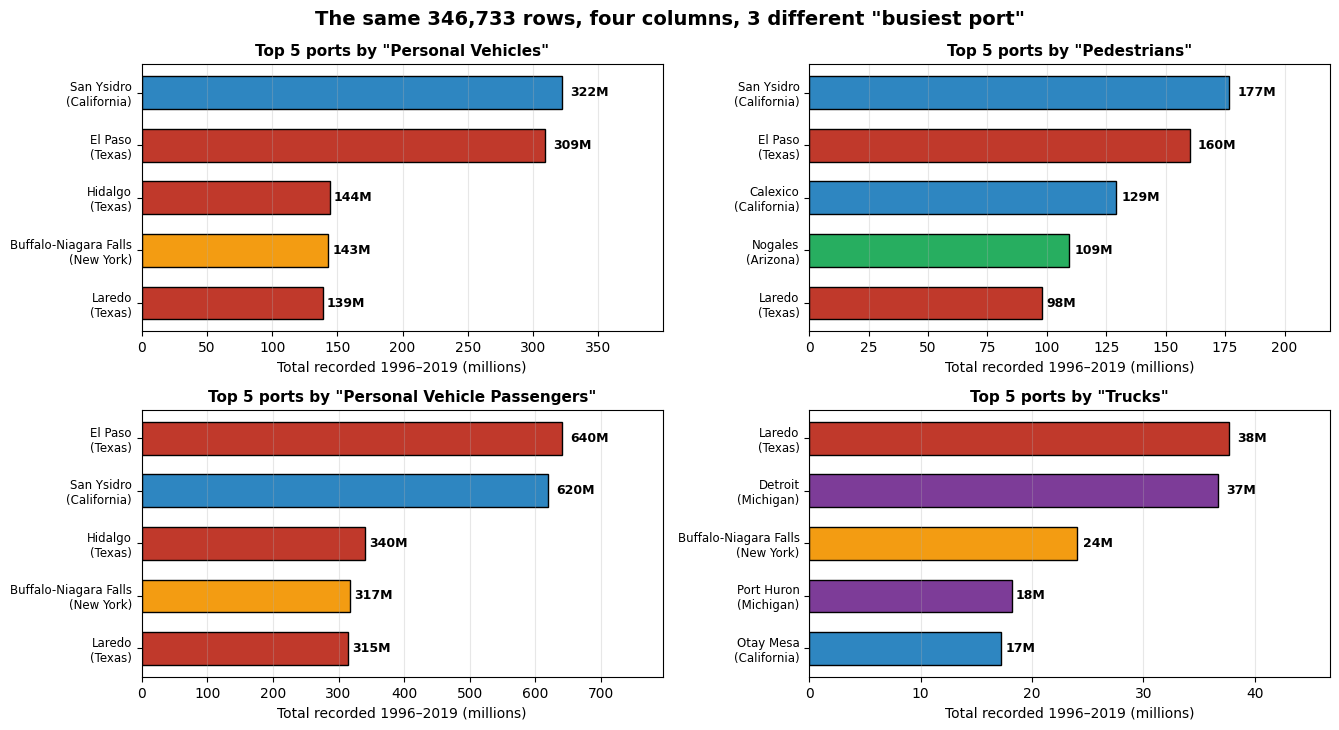

Busiest port, column by column:
   Personal Vehicles            -> San Ysidro (California)
   Pedestrians                  -> San Ysidro (California)
   Personal Vehicle Passengers  -> El Paso (Texas)
   Trucks                       -> Laredo (Texas)

3 different ports win, from the same file, without a single number changing.
The state-level ranking printed in Step 5 cannot show you any of this.


In [8]:
# WHAT: Rank the top five ports four times over, once per traffic column, and draw all four.
# WHY: Step 5 delivered ONE ranking. This asks whether that ranking survives a change of
#      column - because the money in the case study was spent on lanes and pedestrian halls
#      at one gate, not on a state.

import matplotlib.pyplot as plt

# Four columns that a port director would each read differently:
#   Personal Vehicles           = cars      -> how many inspection booths you need
#   Pedestrians                 = people on foot -> how big the pedestrian hall must be
#   Personal Vehicle Passengers = people in cars -> how big the waiting areas must be
#   Trucks                      = commercial traffic -> a different facility entirely
measures = ['Personal Vehicles', 'Pedestrians', 'Personal Vehicle Passengers', 'Trucks']

# One colour per state, so the eye can follow a state across the four panels.
state_color = {'Texas': '#C0392B', 'California': '#2E86C1', 'New York': '#F39C12',
               'Michigan': '#7D3C98', 'Arizona': '#27AE60'}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.4))
winners = {}

for ax, measure in zip(axes.ravel(), measures):
    top5 = (df[df['Measure'] == measure]
            .groupby(['Port Name', 'State'])['Value'].sum()
            .sort_values(ascending=False).head(5))
    winners[measure] = top5.index[0]

    values = top5.values / 1e6                       # millions, so the labels stay readable
    colors = [state_color.get(state, '#7F8C8D') for _, state in top5.index]
    bars = ax.barh(range(len(top5)), values, color=colors, edgecolor='black', height=0.62)
    ax.invert_yaxis()
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels([f'{port}\n({state})' for port, state in top5.index], fontsize=8.5)
    for bar, v in zip(bars, values):
        ax.text(v * 1.02, bar.get_y() + bar.get_height() / 2, f'{v:,.0f}M',
                va='center', ha='left', fontsize=9, weight='bold')
    ax.set_xlim(0, values.max() * 1.24)
    ax.set_title(f'Top 5 ports by "{measure}"', fontsize=11, weight='bold')
    ax.set_xlabel('Total recorded 1996\u20132019 (millions)')
    ax.grid(True, alpha=0.3, axis='x')

n_distinct = len({p for p, _ in winners.values()})
fig.suptitle(f'The same {len(df):,} rows, four columns, '
             f'{n_distinct} different "busiest port"',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Busiest port, column by column:")
for measure, (port, state) in winners.items():
    print(f"   {measure:<28} -> {port} ({state})")
print(f"\n{n_distinct} different ports win, from the same file, without a single number changing.")
print("The state-level ranking printed in Step 5 cannot show you any of this.")


### 👁️ Read the figure

- **Four panels, one per column of the same 346,733-row file.** Every bar is a 1996–2019
  total for one port; the bar colour is its state (red Texas, blue California, orange New
  York, purple Michigan, green Arizona), and each port's state is written under its name.
- **The top bar is not the same port in all four panels.** San Ysidro (California) leads on
  **cars** and on **pedestrians** — the two quantities a gate's inspection lanes and
  pedestrian hall are physically sized for, and precisely what the $625 million rebuilt. El
  Paso (Texas) leads on **people travelling in those cars**. And the **Trucks** panel is a different world:
  Laredo — which sits *last* in all three other panels — wins it outright, Detroit and Port
  Huron appear in no other panel at all, and San Ysidro and El Paso, first or second
  everywhere else, are absent from it entirely.
- **Nothing changed between panels except the column.** Same rows, same `groupby`, same
  ranking code. The disagreement is in the data, not in the method.

**What it proves:** Step 5's recommendation — *concentrate capacity on Personal Vehicle
Passengers at Texas ports* — is one true answer out of several, and it is the one that summed
to a state and picked a column. A port director reading the "Trucks" panel would fund Laredo;
one reading "Pedestrians" would fund San Ysidro. This is Step 1 doing its work: define the
question down to the column and the unit, or the arithmetic will quietly define it for you.


## 💬 Discuss

Your Step 5 recommendation, computed from 346,733 real records, was: *concentrate lane and
staffing capacity on Personal Vehicle Passengers at Texas ports* — Texas totals 3.63
billion crossings, more than any other state, and Personal Vehicle Passengers is 55.8% of
all traffic.

1. San Ysidro is in **California**, it leads every other port on vehicles and on
   pedestrians (you drew that above), and it got the $625 million rebuild. Your
   state-level analysis pointed at Texas. Neither number is wrong — so what
   exactly did the aggregation do to the evidence? Rewrite the recommendation in one
   sentence so it survives contact with a port director.
2. **35.3% of the rows are exactly zero** and the notebook keeps them, arguing "a real zero
   is information". Test that argument: name one analysis in this notebook that the zeros
   make *more* honest, and one they make *less* honest. Would you drop them, keep them, or
   split them out?
3. The data covers January 1996 to March 2019 and every recommendation above averages
   across all of it. A colleague says "23 years of history makes the answer robust". Another
   says "23 years of history makes the answer obsolete". Whose side are you on, and what
   single chart would settle it?


## Part 3: Industry Applications

In [9]:
# WHAT: List real industry applications of data science by sector.
# WHY: Connecting techniques to healthcare, finance, retail, and marketing shows where these skills get used.

print("PART 3: Industry Applications")
print("=" * 70)

applications = {
    "Healthcare": [
        "Patient diagnosis prediction",
        "Drug effectiveness analysis",
        "Hospital resource optimization"
    ],
    "Finance": [
        "Fraud detection",
        "Risk assessment",
        "Stock price prediction"
    ],
    "Retail": [
        "Customer segmentation",
        "Inventory optimization",
        "Sales forecasting"
    ],
    "Marketing": [
        "Campaign effectiveness",
        "Customer behavior analysis",
        "Price optimization"
    ]
}

for industry, uses in applications.items():
    print(f"\n🏢 {industry}:")
    for use in uses:
        print(f"   - {use}")

# ============================================================================

PART 3: Industry Applications

🏢 Healthcare:
   - Patient diagnosis prediction
   - Drug effectiveness analysis
   - Hospital resource optimization

🏢 Finance:
   - Fraud detection
   - Risk assessment
   - Stock price prediction

🏢 Retail:
   - Customer segmentation
   - Inventory optimization
   - Sales forecasting

🏢 Marketing:
   - Campaign effectiveness
   - Customer behavior analysis
   - Price optimization


## Part 4: Project Checklist

In [10]:
# WHAT: Print a reusable project checklist and the notebook summary.
# WHY: A checklist turns the lifecycle into concrete, checkable steps for your own projects.

print("PART 4: Project Checklist")
print("=" * 70)

checklist = {
    "Planning": [
        "✅ Clear problem definition",
        "✅ Data requirements identified",
        "✅ Success criteria defined"
    ],
    "Execution": [
        "✅ Data collected and validated",
        "✅ Data cleaned and prepared",
        "✅ Analysis performed",
        "✅ Results validated"
    ],
    "Presentation": [
        "✅ Insights clearly communicated",
        "✅ Visualizations created",
        "✅ Recommendations provided"
    ]
}

for phase, items in checklist.items():
    print(f"\n📋 {phase}:")
    for item in items:
        print(f"   {item}")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Lifecycle in Practice: Complete workflow from problem to solution
   2. Example Project: Real border-traffic analysis demonstrating all steps
   3. Industry Applications: Real-world use cases
   4. Project Checklist: How to structure your projects

🎯 Key Takeaways:
   - Follow the lifecycle: Problem → Data → Clean → Analyze → Present
   - Start small: Simple projects build confidence
   - Document everything: Clear notebooks are essential
   - Practice: Each project makes you better

📚 Next Steps:
   - Unit 2: Data Cleaning (real-world data cleaning projects)
   - Unit 3: Data Visualization (present your findings)
   - Unit 4: Machine Learning (build predictive models)
   - Start your own project!
""")
print("✅ Data science applications concepts understood!")


PART 4: Project Checklist

📋 Planning:
   ✅ Clear problem definition
   ✅ Data requirements identified
   ✅ Success criteria defined

📋 Execution:
   ✅ Data collected and validated
   ✅ Data cleaned and prepared
   ✅ Analysis performed
   ✅ Results validated

📋 Presentation:
   ✅ Insights clearly communicated
   ✅ Visualizations created
   ✅ Recommendations provided

Summary

✅ What you learned:
   1. Lifecycle in Practice: Complete workflow from problem to solution
   2. Example Project: Real border-traffic analysis demonstrating all steps
   3. Industry Applications: Real-world use cases
   4. Project Checklist: How to structure your projects

🎯 Key Takeaways:
   - Follow the lifecycle: Problem → Data → Clean → Analyze → Present
   - Start small: Simple projects build confidence
   - Document everything: Clear notebooks are essential
   - Practice: Each project makes you better

📚 Next Steps:
   - Unit 2: Data Cleaning (real-world data cleaning projects)
   - Unit 3: Data Visualizati

## ⚠️ Where this breaks

This mini-project is an honest demonstration and a partial one. What it cannot support:

- **Totals answer "how much", never "why" or "what next".** Nothing here can tell you
  whether Texas leads because of demand or because Texas simply has more ports. Ranked
  sums are a description; a staffing decision needs a causal story the sums do not carry.
- **Aggregation destroys the unit the decision is made in.** Money is spent per *port*,
  per *lane*, per *shift*. Summing to state-year hides San Ysidro inside California and
  hides the 6 a.m. peak inside a monthly count. Always aggregate to the unit of the
  decision, not the unit that is convenient.
- **"Missing values: 0" does not mean the data is complete.** It means nothing is blank.
  Crossings that were never recorded, ports that opened mid-series, and definition changes
  across 23 years all look like clean data here. The 35.3% zeros are the visible edge of
  that problem.
- **The assumption that must hold: the recorded measure is the quantity you care about.**
  "Personal Vehicle Passengers" counts *people in cars*, and "Personal Vehicles" counts
  *cars*. Staffing an inspection booth scales with the second; sizing a waiting hall scales
  with the first. Pick the wrong column and every downstream number is precisely correct
  and useless.
- **When a full project is overkill:** if a stakeholder asks a single factual question with
  a known shape — "how many trucks crossed at Laredo in March 2018?" — answer it with one
  filter and move on. Run the five-step lifecycle when the answer will be defended,
  repeated or automated.

**The same shape elsewhere:** a hospital sized by annual admissions when the constraint is
Monday-morning arrivals; a call centre staffed to a daily average when the load is a
two-hour spike; a road widened on annual traffic when the jam is 40 minutes long. In each
case the aggregate was correct and the decision unit was wrong.


## 📚 References

1. Jordan, M. I., & Mitchell, T. M. (2015). *Machine Learning: Trends, Perspectives, and Prospects*. Science, 349(6245), 255-260. <https://doi.org/10.1126/science.aaa8415>
2. LeCun, Y., Bengio, Y., & Hinton, G. (2015). *Deep Learning*. Nature, 521, 436-444. <https://doi.org/10.1038/nature14539>
3. Donoho, D. (2017). *50 Years of Data Science*. Journal of Computational and Graphical Statistics, 26(4), 745-766. <https://doi.org/10.1080/10618600.2017.1384734>
4. Ansari, A. F., Shchur, O., Küken, J., et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv:2510.15821. <https://arxiv.org/abs/2510.15821>
5. Aksu et al. (2024). *GIFT-Eval: A Benchmark for General Time Series Forecasting Model Evaluation*. arXiv:2410.10393. <https://arxiv.org/abs/2410.10393>
